In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../dataset/text/data.csv")

print(df.head())
print("\nTotal samples:", len(df))

                                                text label
0  Education helps individuals grow and succeed i...  real
1     The sun rises in the east and sets in the west  real
2    Reading books improves knowledge and vocabulary  real
3  Hard work always leads to success in the long run  real
4           Technology is changing the world rapidly  real

Total samples: 100


In [3]:
df["label"] = df["label"].map({"real": 0, "fake": 1})

print(df["label"].value_counts())

label
0    50
1    50
Name: count, dtype: int64


In [4]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["text"])
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 1.0

Confusion Matrix:
 [[12  0]
 [ 0  8]]


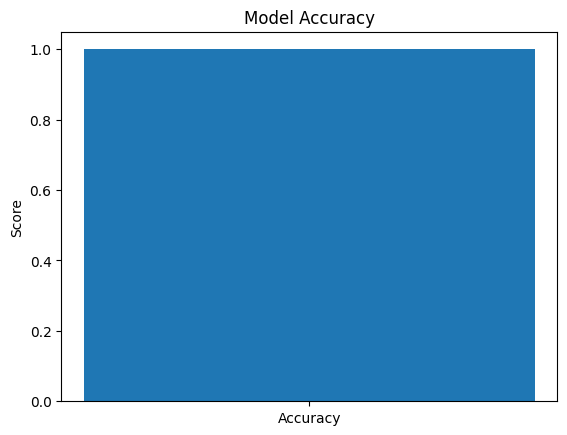

In [10]:
plt.figure()
plt.bar(["Accuracy"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

In [11]:
def predict_text(text):

    vec = vectorizer.transform([text])
    pred = model.predict(vec)

    if pred[0] == 0:
        return "Real Text"
    else:
        return "Fake Text"

In [12]:
test_text = "This content is generated using AI"

result = predict_text(test_text)

print("Text:", test_text)
print("Prediction:", result)

Text: This content is generated using AI
Prediction: Fake Text


In [13]:
test_text = "Heyy i am Ashviniii"

result = predict_text(test_text)

print("Text:", test_text)
print("Prediction:", result)

Text: Heyy i am Ashviniii
Prediction: Real Text


In [14]:
user_input = input("Enter text: ")

print("Result:", predict_text(user_input))

Enter text:  heyyy whatsup


Result: Real Text
